## Time Series Analysis: Analyze temporal patterns in the data using ARIMA
In this Question, i will use ARIMA to create a forcast line graph, i will use the periods 1990 - 2023 to train, 2023 - 2026 as forecast years

## Data Understanding and Preprocessing
import, Columns Understanding, Data type, Raw count etc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Load and clean data
df = pd.read_csv("WEATHER_REPORTS.CSV")


In [2]:
df.head()


,YEAR,MONTH,DAY,MERRA-2 Temperature at 2 Meters (C),MERRA-2 Temperature at 2 Meters Range (C),MERRA-2 Temperature at 2 Meters Maximum (C),MERRA-2 Temperature at 2 Meters Minimum (C),MERRA-2 Precipitation Corrected (mm/day),MERRA-2 Relative Humidity at 2 Meters (%),MERRA-2 Specific Humidity at 2 Meters (g/kg),MERRA-2 Wind Speed at 10 Meters (m/s),Latitude,Longitude
0,1990,1,1,27.65,17.71,37.23,19.51,0.0,19.00,4.03,2.42,9.406,13.462
1,1990,1,2,27.87,17.19,37.21,20.01,0.0,19.12,3.91,1.84,9.406,13.462
2,1990,1,3,27.79,17.03,37.00,19.96,0.0,15.50,3.23,2.38,9.406,13.462
3,1990,1,4,26.89,18.41,36.40,17.99,0.0,19.50,4.03,2.56,9.406,13.462
4,1990,1,5,27.76,18.21,37.14,18.94,0.0,20.50,4.39,2.50,9.406,13.462


## Data Cleaning  
I renamed the columns to Rename columns to remove spaces and standardize names, removed duplicate rows and looked at cleaned data

In [42]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df.set_index('date', inplace=True)

## Feature Engineering 


In [43]:
# Monthly averages for each variable
monthly_data = {
    'Temperature (°C)': df['merra2_temperature_at_2_meters_c'].resample('M').mean(),
    'Precipitation (mm/day)': df['merra2_precipitation_corrected_mmday'].resample('M').mean(),
    'Humidity (%)': df['merra2_relative_humidity_at_2_meters_'].resample('M').mean(),
    'Wind Speed (m/s)': df['merra2_wind_speed_at_10_meters_ms'].resample('M').mean()
}

C:\Users\469775\AppData\Local\Temp\ipykernel_40156\612787087.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Temperature (°C)': df['merra2_temperature_at_2_meters_c'].resample('M').mean(),
C:\Users\469775\AppData\Local\Temp\ipykernel_40156\612787087.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Precipitation (mm/day)': df['merra2_precipitation_corrected_mmday'].resample('M').mean(),
C:\Users\469775\AppData\Local\Temp\ipykernel_40156\612787087.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Humidity (%)': df['merra2_relative_humidity_at_2_meters_'].resample('M').mean(),
C:\Users\469775\AppData\Local\Temp\ipykernel_40156\612787087.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Wind Speed (m/s)': df['merra2_wind_speed_at_10_meters_ms'].resample('M').

## Choosing Algorithms and Feature Selection 

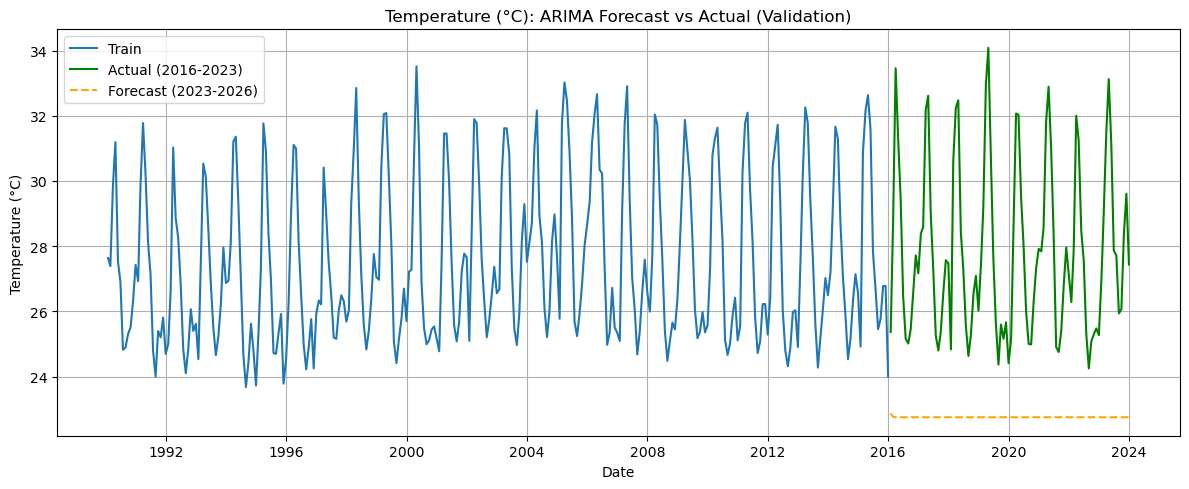

📉 Temperature (°C) RMSE (2016-2023): 5.680


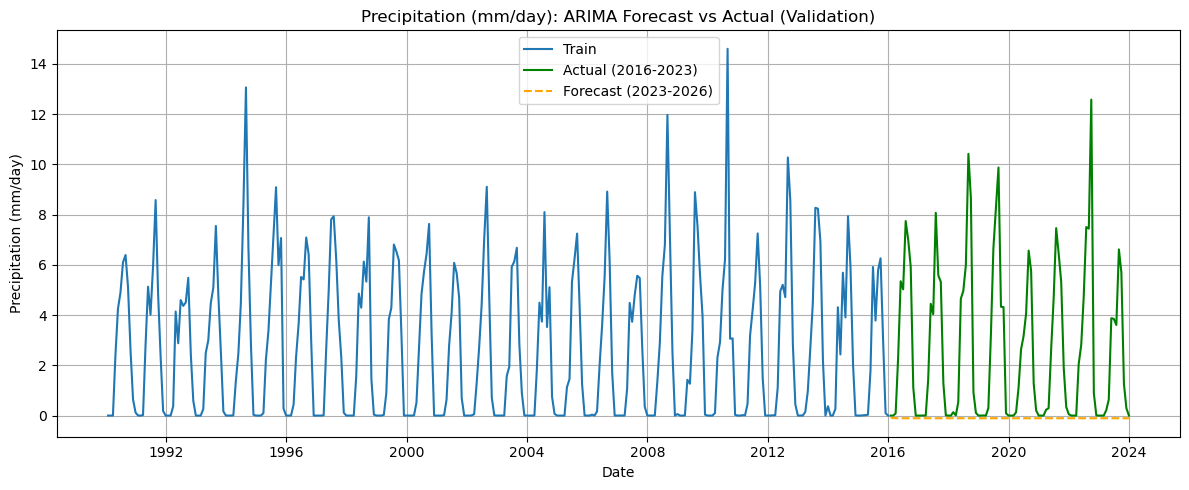

📉 Precipitation (mm/day) RMSE (2016-2023): 4.140


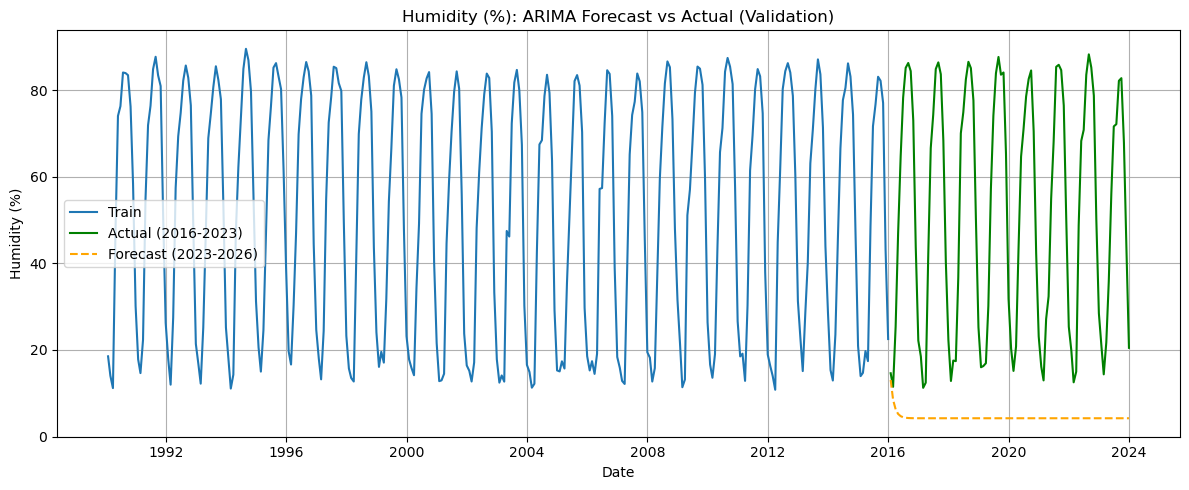

📉 Humidity (%) RMSE (2016-2023): 55.136


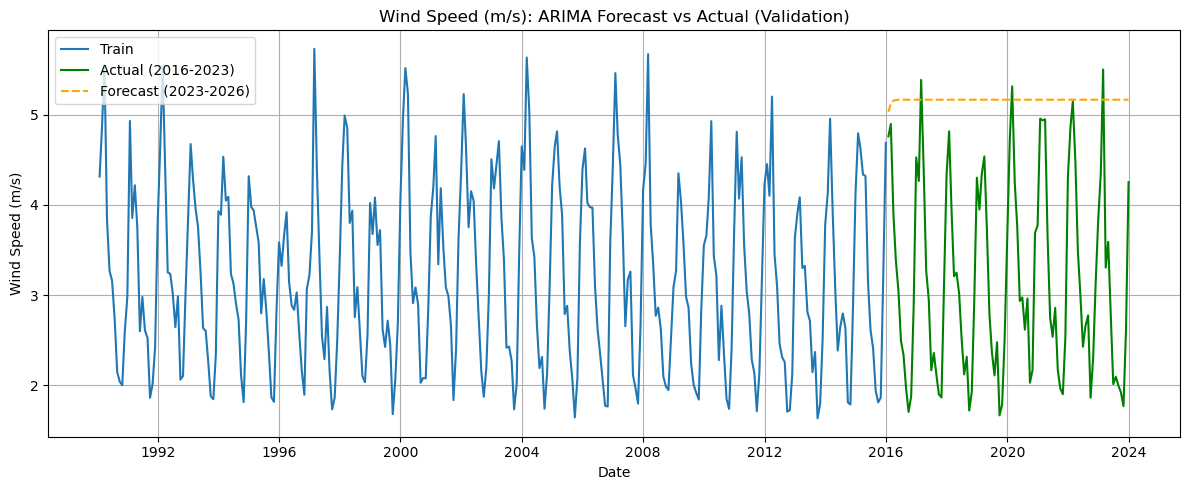

📉 Wind Speed (m/s) RMSE (2016-2023): 2.256


In [44]:
# Forecast function with validation
def forecast_with_validation(series, label):
    # Split data
    train = series[:'2015']
    test = series['2016':'2023']

    # Fit ARIMA
    model = ARIMA(train, order=(1, 1, 1))
    fit = model.fit()

    # Forecast for same length as test
    forecast = fit.forecast(steps=len(test))

    # Plot observed vs forecast
    plt.figure(figsize=(12, 5))
    plt.plot(train, label='Train')
    plt.plot(test, label='Actual (2016-2023)', color='green')
    plt.plot(forecast, label='Forecast (2023-2026)', linestyle='--', color='orange')
    plt.title(f'{label}: ARIMA Forecast vs Actual (Validation)')
    plt.xlabel('Date')
    plt.ylabel(label)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Evaluate forecast
    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f"📉 {label} RMSE (2016-2023): {rmse:.3f}")

# Run forecasts for all variables
for label, series in monthly_data.items():
    forecast_with_validation(series, label)

## Model Interpretation and Deployment 
As seen above
1990 - 2023 to train, 2023 - 2026 as forecast years